In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn 
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random


In [43]:
train_data_dir="data/Training"
test_data_dir="data/Validation"


In [44]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

#training dataset loader
train_dataset = datasets.ImageFolder(
    train_data_dir,
    transform=transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

#test dataset loader

val_dataset = datasets.ImageFolder(
    test_data_dir,
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [45]:
print(train_dataset)

Dataset ImageFolder
    Number of datapoints: 47009
    Root location: data/Training
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [46]:
from collections import Counter

class_counts = Counter(train_dataset.targets)
print(class_counts)

Counter({1: 23766, 0: 23243})


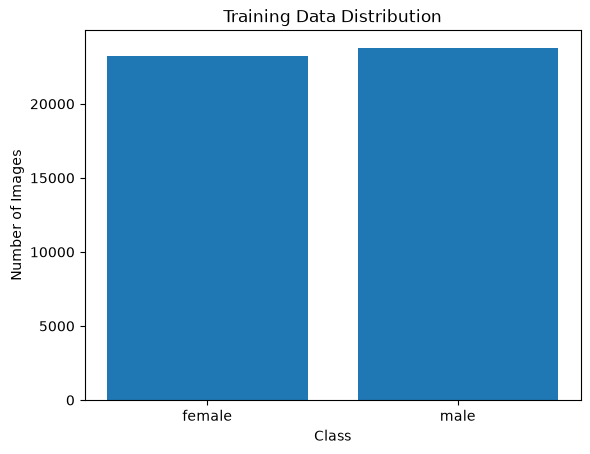

In [47]:
import matplotlib.pyplot as plt

classes = train_dataset.classes
counts = [class_counts[i] for i in range(len(classes))]

plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Data Distribution")
plt.show()

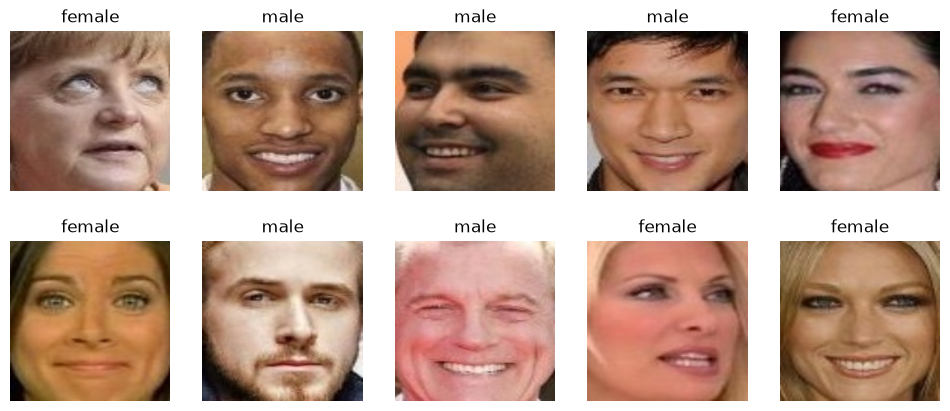

In [48]:


fig, axes = plt.subplots(2, 5, figsize=(12,5))

indices = random.sample(range(len(train_dataset)), 10)

for ax, idx in zip(axes.flatten(), indices):
    img, label = train_dataset[idx]
    ax.imshow(img.permute(1,2,0))
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.show()

creating a layers for model

In [49]:
class Gender(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
             nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128*28*28,512),
        nn.ReLU(),
        nn.Linear(512,2)
        )
        
    def forward(self,x):
        x=self.conv(x)
        x=self.fc(x)
        return x


In [50]:
model = Gender()

In [51]:
print(model)

Gender(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=2, bias=True)
  )
)


selecting cost function and optimizer


In [52]:
loss_fun=nn.CrossEntropyLoss()

In [53]:
optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

starting training

In [56]:
print(len(train_loader))

1470


In [58]:
epochs=10

for epoch in range(epochs):
    model.train()
    running_loss=0
    for images ,labels in train_loader:
        optimizer.zero_grad()
        outputs=model(images)
        loss=loss_fun(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"epoch {epoch+1}:loss={running_loss/len(train_loader):.4f}")



epoch 1:loss=0.2358


KeyboardInterrupt: 